In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib widget

In [2]:
hotels = pd.read_excel("./HotelCustomersDataset.xlsx")
hotels.head()

,ID,Nationality,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,45,371.0,105.3,1,0,3,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,61,280.0,53.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,93,240.0,60.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0,0.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Assignment 1: Subplots

Plot The distribution of lodging revenue for our top 5 countries by revenue ("PRT, "ESP", "FRA", "DEU", "GBR").

**Limit Data to Bookings with RoomNights < 15**

Make sure to share both x and y axes and give them titles!

Remove the extra chart with `ax[row, col].set_axis_off()` if using plt.subplots()


In [3]:
top5 = (hotels
	.loc[hotels["RoomNights"] < 15, :]
	[["Nationality", "LodgingRevenue"]]
	.set_index("Nationality")
	.sort_values(by="LodgingRevenue", ascending=False)
	   )
top5.head()

,LodgingRevenue
Nationality,
USA,9682.40
DEU,9665.66
NAM,9180.00
GBR,9010.00
DEU,7902.00


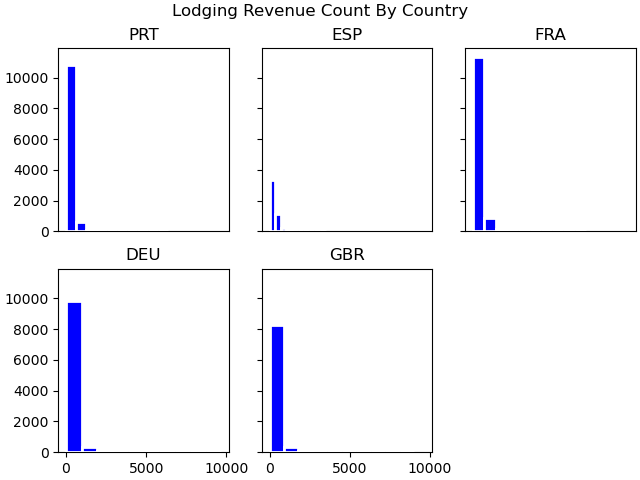

In [4]:
fig, ax = plt.subplots(
	num=1,
	layout="constrained",
	ncols=3,
	nrows=2,
	sharex=True,
	sharey=True
)

fig.suptitle("Lodging Revenue Count By Country")

countries = np.array(["PRT", "ESP", "FRA", "DEU", "GBR", None])
countries = countries.reshape(2, 3)

for i in range(2):
	for j in range(3):
		if (i, j) == (1, 2):
			ax[i, j].set_axis_off()
			continue
		if i == 0:
			ax[i, j].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
		if j != 0:
			ax[i, j].tick_params(axis='y', which='both', bottom=False, labelbottom=False)
		ax[i, j].hist(
			x=top5.loc[countries[i, j], "LodgingRevenue"],
			bins=10,
			range=None,
			rwidth=1,
			bottom=0,
			align="mid",
			zorder=3,
		
			color="b",
			edgecolor="white",
			linewidth=2,
		
			histtype="bar",
			orientation="vertical",
			stacked=False,
		
		
			density=False,
			log=False,
			cumulative=False,
		
			label=countries[i, j],
			alpha=1
		)
		ax[i, j].set_title(countries[i, j]);

# Assignment 2: GridSpec

* Build a Gridspec layout with a line chart plotting Lodging Revenue Vs. Hotel Revenue for all countries at the top of your report.

* Build a bar chart of total revenue (Lodging + Other Revenue) by country for our top 5 countries

* Build a Donut Chart Specifying 67% of the way to our Goal of French Revenue for the year

In [5]:
hotels = hotels.assign(
    date = pd.to_datetime("2018-12-31") - pd.to_timedelta(hotels["DaysSinceCreation"], unit="D"),
    total_revenue = hotels["LodgingRevenue"] + hotels["OtherRevenue"]
)
hotels1 = hotels.set_index("date").sort_index().resample("ME").sum(numeric_only=True)
hotels1.head()

,ID,Age,DaysSinceCreation,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,BookingsNoShowed,BookingsCheckedIn,PersonsNights,...,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom,total_revenue
date,,,,,,,,,,,,,,,,,,,,,
2016-01-31,379755,36919.0,942047,19218,124531.34,52190.50,5,3,629,3029,...,0,0,15,135,44,0,0,0,1,176721.84
2016-02-29,1635272,45916.0,1191109,20804,131689.12,51203.13,1,2,731,3461,...,0,2,9,186,51,0,0,0,1,182892.25
2016-03-31,5233500,76833.0,1838033,61119,443476.86,127336.11,9,3,1741,9026,...,1,0,16,496,152,0,0,0,0,570812.97
2016-04-30,7967358,75218.0,1690729,97010,500966.80,145228.87,10,2,1757,10043,...,0,1,11,603,190,0,3,0,0,646195.67
2016-05-31,11403570,79658.0,1707368,114839,634200.17,143359.35,12,4,1923,10034,...,3,0,3,633,219,0,7,0,1,777559.52


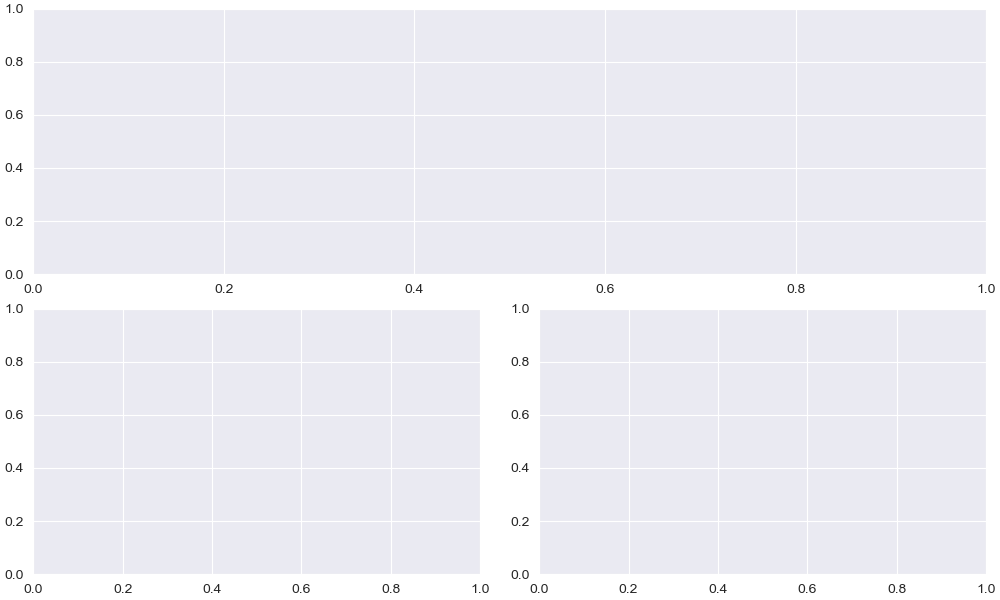

In [6]:
sns.set_style("darkgrid")
# plt.style.use("ggplot")
plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.Set2.colors)

from matplotlib.gridspec import GridSpec
fig, ax = plt.subplots(
	num=2,
	figsize=(10,6),
	layout="constrained",
	nrows=2,
	ncols=2
)
ax1 = ax[0, 0]
ax[0, 1].remove()
gs = ax1.get_gridspec()
ax1.set_subplotspec(gs[0, :])
ax2 = ax[1, 0]
ax3 = ax[1, 1]


# fig = plt.figure(
# 	num=2,
# 	figsize=(10,6),
# 	layout="constrained"
# )
# fig.suptitle("Month-End Revenue Report", fontsize=20)
# gs = GridSpec(nrows=2, ncols=2, figure=fig)
# ax1 = fig.add_subplot(gs[0, 0:2])
# ax2 = fig.add_subplot(gs[1, 0])
# ax3 = fig.add_subplot(gs[1, 1])

In [7]:
ax1.plot(hotels1.index,
		 hotels1["LodgingRevenue"] / 1000000,
		 label="Lodging Revenue")
ax1.plot(hotels1.index,
		 hotels1["OtherRevenue"] / 1000000,
		 label="Other Revenue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Revenue (in millions)")
ax1.legend(frameon=False, fontsize=10)
ax1.set_title("Monthly Hotel Revenue", fontsize=15)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
# display(fig);

In [8]:
hotels2 = (hotels
	.groupby("Nationality")
	.agg({"total_revenue":"sum"})
	.sort_values(by="total_revenue", ascending=False)
	.iloc[:5, :])
ax2.bar(x=hotels2.index, height=hotels2["total_revenue"] / 10000000, color=["b", "0.0", "g", "r", "y"])
ax2.set_xlabel("Nationality")
ax2.set_ylabel("Revenue (in millions)")
ax2.set_title("Revenue by Country", fontsize=15)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
# display(fig);

In [9]:
wedges, texts, autotexts = ax3.pie(
	[100*2/3, 100/3],
	autopct="%1.1f%%",
	pctdistance=0,
	textprops={"fontsize":20},

	colors=("b", "white"),
	wedgeprops={"width":0.2},

	startangle=90,
	counterclock=False
)
ax3.set_title("Percent of 2018 French Revenue Goal Met", fontsize=15)
# ax2.spines["top"].set_visible(False)
# ax2.spines["right"].set_visible(False)
for i, item in enumerate(autotexts):
	if i==1:
		item.set_text("")

plt.savefig("ax1")
# display(fig);